# Problema 2 — Fruits and Vegetables Recognizer

**Proyecto Final · Text Mining & Image Recognition**
Postgrado en Análisis y Predicción de Datos — Tercer Trimestre, 2026

> 
---

##  Ejecutar en VS Code (local)

Este notebook está preparado para correr **localmente en VS Code**, no en Colab.

**1. Entorno.**  **En Windows, cree el entorno virtual en una ruta corta .**
TensorFlow instala cabeceras C++ con rutas larguísimas (`tensorflow/include/external/
com_github_grpc_grpc/src/core/credentials/call/external/...`) y si la carpeta del proyecto ya
es profunda, la instalación falla con `OSError: [Errno 2] No such file or directory` al chocar
con el límite `MAX_PATH` de 260 caracteres de Windows:

```powershell
python -m venv C:\venvs\tmir
C:\venvs\tmir\Scripts\activate
pip install -r requirements.txt
```


**2. Kernel.** Abra este notebook, pulse `Select Kernel` arriba a la derecha → `Python
Environments` → el intérprete de `C:\venvs\tmir`. Necesita las extensiones *Python* y
*Jupyter* de VS Code.

**3. Dataset.** Se descarga solo desde Kaggle (§2.1). Requiere el token de Kaggle en
`~/.kaggle/kaggle.json`; si prefiere no configurarlo, la misma sección explica la descarga
manual.

**4. Ejecutar.** `Run All`. El notebook detecta el hardware y ajusta las épocas: **40 con GPU,
20 en CPU** (`EarlyStopping` suele cortar antes en ambos casos).

>  **Sobre la GPU en Windows.** TensorFlow **≥ 2.11 no soporta GPU en Windows nativo**,
> aunque haya CUDA instalado: el propio TF lo advierte y cae a CPU. Para usar GPU haría falta
> WSL2 o el plugin *TensorFlow-DirectML*. No es un problema: el dataset es pequeño, así que en
> CPU el entrenamiento es perfectamente viable.
>
>  Para una pasada rápida que solo verifique que el pipeline corre, baje `EPOCAS` a 3 en la
> celda de entrenamiento. Los resultados no servirán, pero valida todo en un par de minutos.

---

## Enunciado

**Objetivo.** Entrenar una CNN que distinga entre frutas y verduras, robusta a variaciones de
**tamaño, rotación e iluminación**. Se comparan **tres arquitecturas** y se justifica cuál
funciona mejor y por qué.

**Plan de trabajo**

| Parte | Contenido |
|---|---|
| 2.1 | Descarga del dataset de Kaggle y selección de 3 frutas + 3 vegetales |
| 2.2 | *Data augmentation* y preprocesamiento con `ImageDataGenerator` / `flow_from_directory` |
| 2.3 | Tres arquitecturas CNN: baseline, profunda con *BatchNorm*, y *transfer learning* |
| 2.4 | Entrenamiento con split train / validation / test |
| 2.5 | Comparación, evaluación en test y respuesta a la pregunta del enunciado |

## 2.0 Entorno y semillas

**Nota importante sobre la versión de Keras.** El enunciado pide resolver el preprocesamiento
con `ImageDataGenerator` y `flow_from_directory`, que son API de **Keras 2**. TensorFlow ≥ 2.16
usa **Keras 3** por defecto, donde `ImageDataGenerator` fue eliminado. Por eso `requirements.txt`
incluye `tf-keras` y aquí se activa `TF_USE_LEGACY_KERAS=1` **antes** de importar TensorFlow:
así `tf.keras` vuelve a ser Keras 2 y el código del enunciado funciona tal cual.


*Detalle de implementación:* con el modo legado activo, `tf.keras` deja de ser el paquete Keras
y pasa a ser un *lazy loader* que reenvía a `tf_keras`. Ese objeto **no expone `__version__`**,
así que la versión se lee del paquete real — de ahí el `getattr` con respaldo en la celda.

In [1]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"   # <- debe ir ANTES de importar tensorflow
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"  # silencia los avisos informativos de oneDNN

import random, shutil, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers, callbacks

try:
    from tensorflow.keras.preprocessing.image import ImageDataGenerator
except ImportError as e:      # tf.keras esta corriendo sobre Keras 3
    raise ImportError(
        "ImageDataGenerator no existe en Keras 3.\n"
        "Solucion: pip install tf-keras , REINICIAR EL KERNEL y reejecutar esta celda."
    ) from e

# Con TF_USE_LEGACY_KERAS=1, tf.keras es un lazy loader que apunta a tf_keras y no
# expone __version__; hay que leerla del paquete real.
VERSION_KERAS = getattr(keras, "__version__", None)
if VERSION_KERAS is None:
    import tf_keras
    VERSION_KERAS = tf_keras.__version__

SEMILLA = 42
random.seed(SEMILLA); np.random.seed(SEMILLA); tf.random.set_seed(SEMILLA)

HAY_GPU = bool(tf.config.list_physical_devices("GPU"))

print("TensorFlow:", tf.__version__, "| Keras:", VERSION_KERAS)
print("ImageDataGenerator viene de:", ImageDataGenerator.__module__)
print("GPU:", "si" if HAY_GPU else "no -> se entrenara en CPU")

assert VERSION_KERAS.startswith("2"), (
    f"Se esperaba Keras 2 y hay {VERSION_KERAS}.\n"
    "Instale tf-keras (pip install tf-keras), REINICIE EL KERNEL y reejecute."
)

TensorFlow: 2.21.0 | Keras: 2.21.0
ImageDataGenerator viene de: tf_keras.src.preprocessing.image
GPU: no -> se entrenara en CPU


## 2.1 Dataset

Se usa el dataset **Fruit and Vegetable Image Recognition** de Kaggle
(`kritikseth/fruit-and-vegetable-image-recognition`), que ya viene separado en las carpetas
`train/`, `validation/` y `test/`, con una subcarpeta por clase.

De las 36 clases disponibles se seleccionan **3 frutas y 3 vegetales**, eligiendo categorías
visualmente distintas entre sí pero con pares que puedan confundirse (manzana/tomate son
ambos redondos y rojos), para que el problema no sea trivial:

| Frutas | Vegetales |
|---|---|
| `apple` | `carrot` |
| `banana` | `cucumber` |
| `grapes` | `tomato` |

> 🔑 **Token de Kaggle (solo la primera vez).** `kagglehub` necesita credenciales:
> vaya a *kaggle.com → Settings → API → Create New Token*, se descarga un `kaggle.json`, y
> colóquelo en `C:\Users\<usuario>\.kaggle\kaggle.json` (Windows) o `~/.kaggle/kaggle.json`
> (macOS/Linux).
>
> **Sin token:** descargue el ZIP desde la página del dataset, descomprímalo y deje la carpeta
> que contiene `train/`, `validation/` y `test/` en
> `datos/fruit-and-vegetable-image-recognition/`. La celda la detectará y no intentará
> descargar nada.

In [2]:
RAIZ        = Path.cwd()
DIR_DATOS   = RAIZ / "datos"
DIR_SALIDAS = RAIZ / "salidas" / "problema2"
DIR_SALIDAS.mkdir(parents=True, exist_ok=True)

FRUTAS    = ["apple", "banana", "grapes"]
VEGETALES = ["carrot", "cucumber", "tomato"]
CLASES    = sorted(FRUTAS + VEGETALES)
N_CLASES  = len(CLASES)

# --- Descarga (Colab) o reutilizacion de una copia local -------------------------------
ORIGEN = DIR_DATOS / "fruit-and-vegetable-image-recognition"

if not ORIGEN.exists():
    import kagglehub
    ruta = Path(kagglehub.dataset_download("kritikseth/fruit-and-vegetable-image-recognition"))
    # el zip puede traer un nivel extra de carpeta; se busca la que contenga "train"
    candidatas = [p for p in [ruta, *ruta.iterdir()] if (p / "train").is_dir()]
    ORIGEN = candidatas[0]

print("Dataset original en:", ORIGEN)
print("Clases disponibles :", len(list((ORIGEN / "train").iterdir())))

Dataset original en: C:\Users\jorge.perez\.cache\kagglehub\datasets\kritikseth\fruit-and-vegetable-image-recognition\versions\8
Clases disponibles : 36


In [3]:
# Se copian SOLO las 6 clases elegidas a datos/frutas_verduras/{train,validation,test}/<clase>
BASE = DIR_DATOS / "frutas_verduras"

if not BASE.exists():
    for split in ["train", "validation", "test"]:
        for clase in CLASES:
            src = ORIGEN / split / clase
            dst = BASE / split / clase
            dst.mkdir(parents=True, exist_ok=True)
            for img in src.iterdir():
                if img.suffix.lower() in {".jpg", ".jpeg", ".png"}:
                    shutil.copy(img, dst / img.name)

conteo = pd.DataFrame(
    {split: {clase: len(list((BASE / split / clase).glob("*"))) for clase in CLASES}
     for split in ["train", "validation", "test"]}
)
conteo["total"] = conteo.sum(axis=1)
conteo["tipo"]  = ["fruta" if c in FRUTAS else "vegetal" for c in conteo.index]
conteo.loc["TOTAL"] = [*conteo[["train", "validation", "test", "total"]].sum(), ""]
conteo

,train,validation,test,total,tipo
apple,68,10,10,88,fruta
banana,75,9,9,93,fruta
carrot,82,9,10,101,vegetal
cucumber,94,10,10,114,vegetal
grapes,100,9,10,119,fruta
tomato,92,10,10,112,vegetal
TOTAL,511,57,59,627,


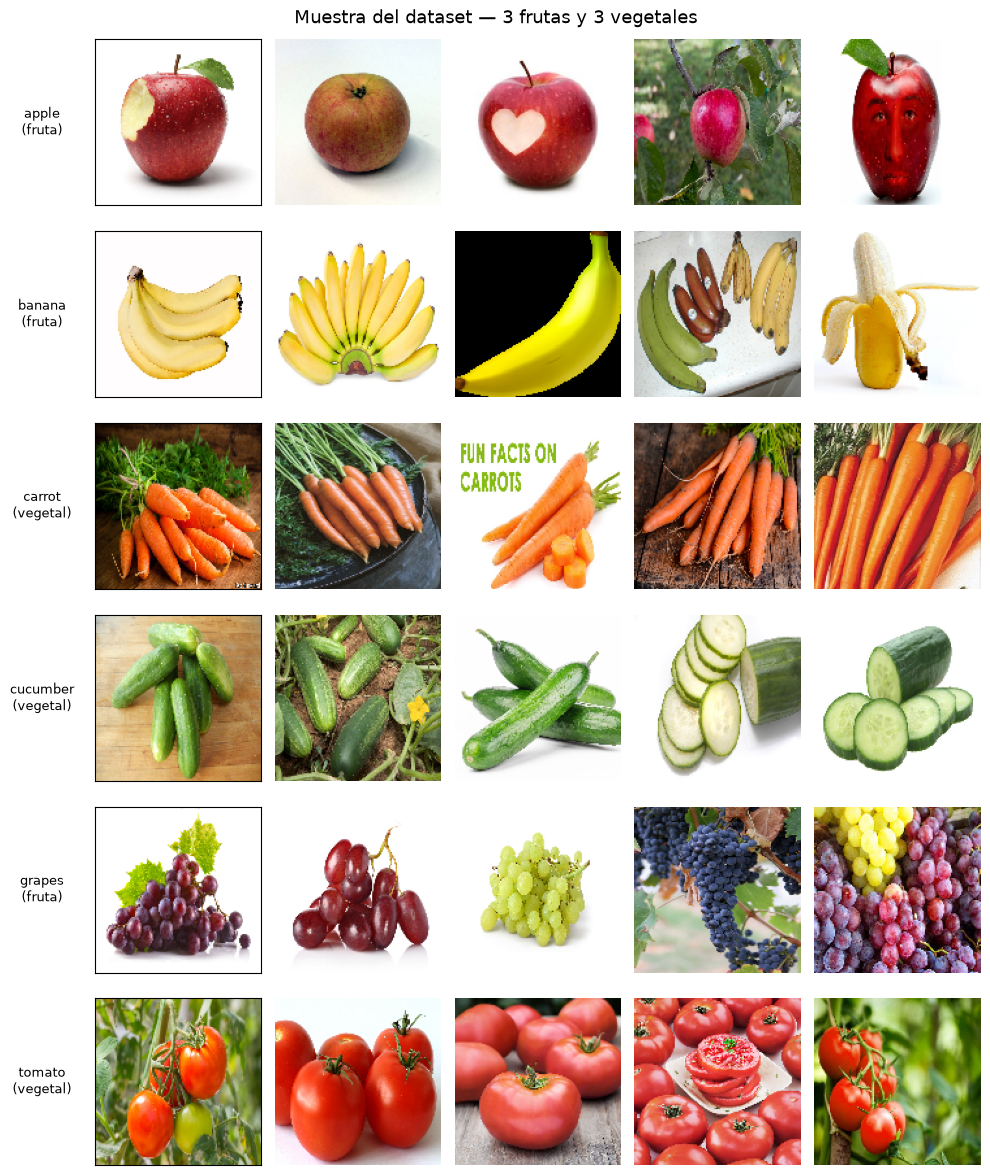

In [4]:
# Muestra de imagenes crudas (una fila por clase)
fig, axes = plt.subplots(N_CLASES, 5, figsize=(10, 2 * N_CLASES))
for i, clase in enumerate(CLASES):
    archivos = sorted((BASE / "train" / clase).glob("*"))[:5]
    for j, ax in enumerate(axes[i]):
        ax.axis("off")
        if j < len(archivos):
            ax.imshow(keras.utils.load_img(archivos[j], target_size=(128, 128)))
    etiqueta = "fruta" if clase in FRUTAS else "vegetal"
    axes[i, 0].set_ylabel(clase)
    axes[i, 0].axis("on"); axes[i, 0].set_xticks([]); axes[i, 0].set_yticks([])
    axes[i, 0].set_ylabel(f"{clase}\n({etiqueta})", fontsize=9, rotation=0,
                          labelpad=38, va="center")
plt.suptitle("Muestra del dataset — 3 frutas y 3 vegetales", fontsize=13)
plt.tight_layout()
plt.savefig(DIR_SALIDAS / "muestra_dataset.png", bbox_inches="tight")
plt.show()

## 2.2 Data augmentation y preprocesamiento

**Decisiones tomadas y por qué:**

- **Color, no escala de grises.** El color es la señal discriminante más fuerte de este
  problema: un plátano amarillo, una zanahoria naranja y un pepino verde se separan casi por
  matiz. Pasar a grises tiraría esa información y obligaría a la red a aprender solo forma y
  textura, que es justamente donde manzana y tomate se confunden. Se usan **3 canales RGB**.
- **Tamaño de entrada 128×128.** Suficiente para conservar textura (la piel del pepino, el
  racimo de uvas) y barato de entrenar. Las imágenes originales tienen tamaños heterogéneos,
  así que `flow_from_directory` las redimensiona a un estándar único.
- **Normalización.** `rescale=1./255` lleva los píxeles de `[0, 255]` a `[0, 1]`, que es lo
  que esperan las activaciones ReLU y el optimizador Adam.
- **Augmentation solo en entrenamiento.** Validación y test se dejan intactos (solo rescale),
  porque queremos medir el desempeño sobre imágenes reales, no aumentadas.

El enunciado pide robustez ante **tamaño, rotación e iluminación**; cada transformación ataca
una de esas fuentes de variación:

| Transformación | Parámetro | Robustez que aporta |
|---|---|---|
| Rotación | `rotation_range=30` | objeto fotografiado en cualquier ángulo |
| Zoom | `zoom_range=0.25` | **tamaño** / distancia a la cámara |
| Desplazamiento | `width/height_shift_range=0.2` | objeto descentrado |
| Flip horizontal | `horizontal_flip=True` | frutas y verduras no tienen orientación canónica |
| Shear | `shear_range=0.15` | deformación de perspectiva |
| Brillo | `brightness_range=[0.6, 1.4]` | **iluminación** (sombra vs. foco directo) |
| Canal | `channel_shift_range=25` | dominante de color de la fuente de luz |

In [5]:
IMG_SIZE   = (128, 128)
BATCH_SIZE = 32

gen_entrenamiento = ImageDataGenerator(
    rescale=1. / 255,
    rotation_range=30,
    width_shift_range=0.20,
    height_shift_range=0.20,
    shear_range=0.15,
    zoom_range=0.25,
    horizontal_flip=True,
    brightness_range=[0.6, 1.4],
    channel_shift_range=25.0,
    fill_mode="nearest",
)

# Validacion y test: solo normalizacion
gen_evaluacion = ImageDataGenerator(rescale=1. / 255)

flujo_train = gen_entrenamiento.flow_from_directory(
    str(BASE / "train"), target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode="categorical", classes=CLASES, shuffle=True, seed=SEMILLA)

flujo_val = gen_evaluacion.flow_from_directory(
    str(BASE / "validation"), target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode="categorical", classes=CLASES, shuffle=False)

flujo_test = gen_evaluacion.flow_from_directory(
    str(BASE / "test"), target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode="categorical", classes=CLASES, shuffle=False)

print("\nMapeo clase -> indice:", flujo_train.class_indices)

Found 511 images belonging to 6 classes.


Found 57 images belonging to 6 classes.


Found 59 images belonging to 6 classes.



Mapeo clase -> indice: {'apple': 0, 'banana': 1, 'carrot': 2, 'cucumber': 3, 'grapes': 4, 'tomato': 5}


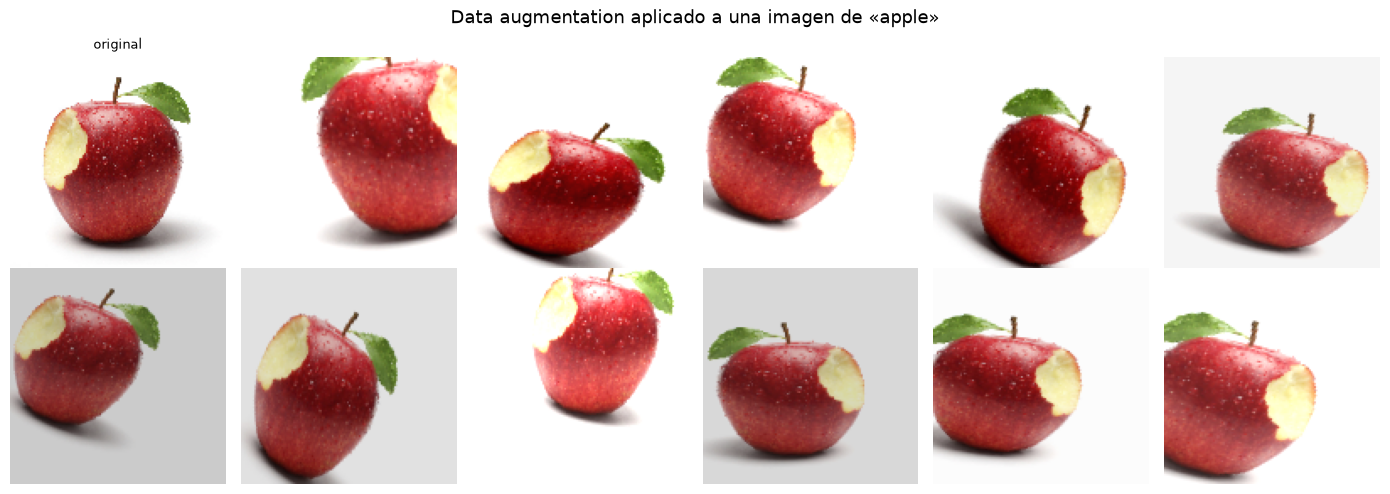

In [6]:
# Efecto visual del augmentation sobre una sola imagen
muestra = keras.utils.img_to_array(
    keras.utils.load_img(sorted((BASE / "train" / CLASES[0]).glob("*"))[0],
                         target_size=IMG_SIZE))[np.newaxis, ...]

fig, axes = plt.subplots(2, 6, figsize=(14, 5))
axes[0, 0].imshow(muestra[0].astype("uint8")); axes[0, 0].set_title("original", fontsize=9)
axes[0, 0].axis("off")

iterador = gen_entrenamiento.flow(muestra, batch_size=1, seed=SEMILLA)
for ax in axes.flat[1:]:
    ax.imshow(next(iterador)[0])
    ax.axis("off")
plt.suptitle(f"Data augmentation aplicado a una imagen de «{CLASES[0]}»", fontsize=13)
plt.tight_layout()
plt.savefig(DIR_SALIDAS / "data_augmentation.png", bbox_inches="tight")
plt.show()

## 2.3 Tres arquitecturas CNN

Las tres comparten entrada (`128×128×3`), salida (`softmax` de 6 clases) y pérdida
(`categorical_crossentropy`), para que la comparación sea justa. Lo que cambia es la
**capacidad y la estrategia**:

### Modelo A — CNN baseline
Tres bloques `Conv(3×3) → MaxPool`, con 32 / 64 / 128 filtros, y una densa de 128 neuronas
con `Dropout(0.5)`. Es la arquitectura de libro: sirve de piso de comparación y permite ver
cuánto aporta cada mejora posterior. El kernel 3×3 es el estándar porque dos capas de 3×3
cubren el mismo campo receptivo que una de 5×5 con menos parámetros y una no-linealidad extra.

### Modelo B — CNN profunda con BatchNormalization
Cuatro bloques dobles `Conv → Conv → BN → MaxPool` (32/64/128/256 filtros) y
`GlobalAveragePooling` en vez de `Flatten`. Tres cambios deliberados frente a A:
- **BatchNormalization** estabiliza y acelera el entrenamiento, y actúa como regularizador.
  Se usa `momentum=0.85` en lugar del `0.99` por defecto: BN normaliza con estadísticas del
  batch al entrenar pero con **medias móviles** al inferir, y con solo ~16 batches por época
  unas medias tan lentas no alcanzan a converger, lo que degradaría la validación.
- **Doble convolución por bloque** aumenta el campo receptivo antes de reducir resolución.
- **GlobalAveragePooling** elimina la densa gigante del `Flatten` (de ~2M parámetros a ~0),
  que es la principal fuente de sobreajuste en datasets pequeños.

### Modelo C — Transfer learning con MobileNetV2
Base `MobileNetV2` preentrenada en ImageNet, **congelada**, más una cabeza densa propia.
ImageNet ya contiene frutas y verduras, así que sus filtros de bordes, texturas y color son
directamente reutilizables. Con pocos miles de imágenes es de esperar que gane: no tiene que
aprender de cero a ver.

In [7]:
ENTRADA = (*IMG_SIZE, 3)

def modelo_a_baseline():
    """CNN clasica de 3 bloques Conv-Pool."""
    m = models.Sequential([
        layers.Input(shape=ENTRADA),
        layers.Conv2D(32, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(2),
        layers.Conv2D(64, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(2),
        layers.Conv2D(128, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(2),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(N_CLASES, activation="softmax"),
    ], name="A_baseline")
    m.compile(optimizer=optimizers.Adam(1e-3),
              loss="categorical_crossentropy", metrics=["accuracy"])
    return m


def modelo_b_profunda():
    """CNN profunda con BatchNorm y GlobalAveragePooling."""
    def bloque(x, filtros):
        x = layers.Conv2D(filtros, 3, padding="same", activation="relu")(x)
        x = layers.Conv2D(filtros, 3, padding="same", activation="relu")(x)
        # momentum=0.85 en vez del 0.99 por defecto: con ~500 imagenes solo hay 16
        # batches por epoca, y unas medias moviles tan lentas no convergerian antes
        # de que EarlyStopping corte, degradando la inferencia.
        x = layers.BatchNormalization(momentum=0.85)(x)
        return layers.MaxPooling2D(2)(x)

    entrada = layers.Input(shape=ENTRADA)
    x = entrada
    for f in (32, 64, 128, 256):
        x = bloque(x, f)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.4)(x)
    salida = layers.Dense(N_CLASES, activation="softmax")(x)

    m = models.Model(entrada, salida, name="B_profunda_bn")
    m.compile(optimizer=optimizers.Adam(1e-3),
              loss="categorical_crossentropy", metrics=["accuracy"])
    return m


def modelo_c_transfer():
    """MobileNetV2 preentrenada en ImageNet, congelada, + cabeza propia."""
    base = keras.applications.MobileNetV2(
        input_shape=ENTRADA, include_top=False, weights="imagenet")
    base.trainable = False

    m = models.Sequential([
        layers.Input(shape=ENTRADA),
        base,
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.3),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(N_CLASES, activation="softmax"),
    ], name="C_mobilenetv2")
    m.compile(optimizer=optimizers.Adam(1e-3),
              loss="categorical_crossentropy", metrics=["accuracy"])
    return m


ARQUITECTURAS = {
    "A_baseline":    modelo_a_baseline,
    "B_profunda_bn": modelo_b_profunda,
    "C_mobilenetv2": modelo_c_transfer,
}

for nombre, constructor in ARQUITECTURAS.items():
    m = constructor()
    entrenables = int(sum(np.prod(w.shape) for w in m.trainable_weights))
    print(f"{nombre:<16} capas={len(m.layers):>3}  parametros entrenables={entrenables:>10,}")

A_baseline       capas= 10  parametros entrenables= 4,288,454
B_profunda_bn    capas= 21  parametros entrenables= 1,240,550


C_mobilenetv2    capas=  6  parametros entrenables=   164,742


In [8]:
modelo_a_baseline().summary()

Model: "A_baseline"


_________________________________________________________________


 Layer (type)                Output Shape              Param #   


 conv2d_11 (Conv2D)          (None, 128, 128, 32)      896       


 max_pooling2d_7 (MaxPoolin  (None, 64, 64, 32)        0         


...

 dense_7 (Dense)             (None, 6)                 774       


Total params: 4288454 (16.36 MB)


Trainable params: 4288454 (16.36 MB)


Non-trainable params: 0 (0.00 Byte)


_________________________________________________________________


## 2.4 Entrenamiento

El dataset ya trae la partición **train / validation / test** que pide el enunciado:
entrenamiento ajusta los pesos, validación decide cuándo parar y cuál modelo elegir, y test
—que ningún modelo ve durante el entrenamiento— da la estimación final e imparcial.

Callbacks:
- `EarlyStopping(patience=8, restore_best_weights=True)` — corta cuando `val_accuracy` deja de
  mejorar y devuelve los pesos de la mejor época, no los de la última.
- `ReduceLROnPlateau` — baja el *learning rate* cuando la validación se estanca, para afinar.

In [9]:
# En CPU se recorta el presupuesto de epocas para que la corrida local sea viable.
# EarlyStopping (patience=8) suele detener antes en ambos casos.
EPOCAS = 40 if HAY_GPU else 20
print(f"Entrenando {EPOCAS} epocas por modelo ({'GPU' if HAY_GPU else 'CPU'})\n")

def entrenar(nombre, constructor):
    print("=" * 78)
    print("Entrenando", nombre)
    print("=" * 78)
    tf.keras.backend.clear_session()
    random.seed(SEMILLA); np.random.seed(SEMILLA); tf.random.set_seed(SEMILLA)

    modelo = constructor()
    cbs = [
        callbacks.EarlyStopping(monitor="val_accuracy", patience=8,
                                restore_best_weights=True, verbose=1),
        callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=4,
                                    min_lr=1e-6, verbose=1),
    ]
    historial = modelo.fit(flujo_train, validation_data=flujo_val,
                           epochs=EPOCAS, callbacks=cbs, verbose=2)

    # Se guarda en HDF5 legado y no en el formato .keras: en Windows, tf_keras arma las
    # rutas internas del .keras con os.path.join, generando claves con contrabarra
    # ("layers\dense") que HDF5 no interpreta como jerarquia, y el modelo no vuelve a cargar.
    modelo.save(DIR_SALIDAS / f"modelo_{nombre}.h5")
    return modelo, historial.history


modelos, historiales = {}, {}
for nombre, constructor in ARQUITECTURAS.items():
    modelos[nombre], historiales[nombre] = entrenar(nombre, constructor)

json.dump({k: {m: list(map(float, v)) for m, v in h.items()} for k, h in historiales.items()},
          open(DIR_SALIDAS / "historiales.json", "w"), indent=2)

# Comprobacion de que los pesos en disco son reutilizables, no solo que el archivo existe
print("\nVerificacion de los modelos guardados:")
for nombre in ARQUITECTURAS:
    ruta = DIR_SALIDAS / f"modelo_{nombre}.h5"
    recargado = keras.models.load_model(ruta)
    assert recargado.count_params() == modelos[nombre].count_params()
    print(f"  {nombre:<16} recarga OK  ({ruta.stat().st_size/1e6:5.1f} MB, "
          f"{recargado.count_params():,} parametros)")

Entrenando 20 epocas por modelo (CPU)

Entrenando A_baseline


Epoch 1/20


C:\venvs\tmir\Lib\site-packages\PIL\Image.py:1136: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


16/16 - 18s - loss: 1.6781 - accuracy: 0.2759 - val_loss: 1.5413 - val_accuracy: 0.3333 - lr: 0.0010 - 18s/epoch - 1s/step


Epoch 2/20


...

Restoring model weights from the end of the best epoch: 4.



Verificacion de los modelos guardados:


  A_baseline       recarga OK  ( 51.5 MB, 4,288,454 parametros)


  B_profunda_bn    recarga OK  ( 15.0 MB, 1,241,510 parametros)


  C_mobilenetv2    recarga OK  ( 11.4 MB, 2,422,726 parametros)


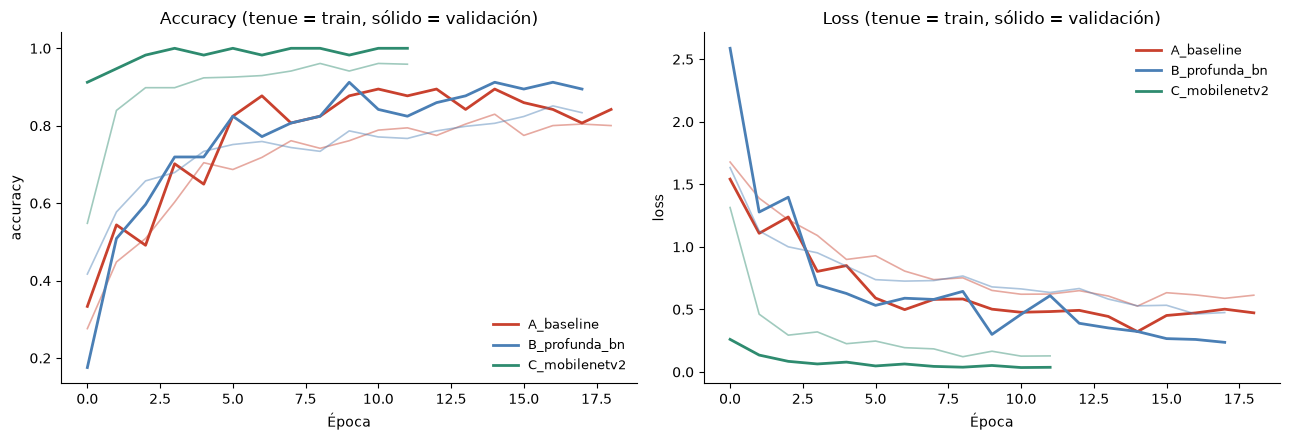

In [10]:
# Curvas de aprendizaje de las tres arquitecturas
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
colores = {"A_baseline": "#c9412e", "B_profunda_bn": "#4a7fb5", "C_mobilenetv2": "#2e8b6f"}

for nombre, h in historiales.items():
    axes[0].plot(h["accuracy"], color=colores[nombre], alpha=0.45, linewidth=1.2)
    axes[0].plot(h["val_accuracy"], color=colores[nombre], linewidth=2, label=nombre)
    axes[1].plot(h["loss"], color=colores[nombre], alpha=0.45, linewidth=1.2)
    axes[1].plot(h["val_loss"], color=colores[nombre], linewidth=2, label=nombre)

axes[0].set_title("Accuracy (tenue = train, sólido = validación)")
axes[1].set_title("Loss (tenue = train, sólido = validación)")
for ax in axes:
    ax.set_xlabel("Época"); ax.legend(frameon=False, fontsize=9)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
axes[0].set_ylabel("accuracy"); axes[1].set_ylabel("loss")
plt.tight_layout()
plt.savefig(DIR_SALIDAS / "curvas_entrenamiento.png", bbox_inches="tight")
plt.show()

## 2.5 Comparación y evaluación en el conjunto de prueba

La elección del mejor modelo se hace por **`val_accuracy`**; el conjunto de **test** se
reserva para reportar el desempeño final, ya sin decisiones de por medio.

In [11]:
from sklearn.metrics import classification_report, confusion_matrix

filas = []
for nombre, modelo in modelos.items():
    h = historiales[nombre]
    val_loss, val_acc   = modelo.evaluate(flujo_val,  verbose=0)
    test_loss, test_acc = modelo.evaluate(flujo_test, verbose=0)
    filas.append({
        "Modelo": nombre,
        "Parámetros entrenables": int(sum(np.prod(w.shape) for w in modelo.trainable_weights)),
        "Épocas": len(h["accuracy"]),
        "Train acc": round(max(h["accuracy"]), 4),
        "Val acc": round(val_acc, 4),
        "Test acc": round(test_acc, 4),
        "Test loss": round(test_loss, 4),
        "Gap train-val": round(max(h["accuracy"]) - val_acc, 4),
    })

comparativa = pd.DataFrame(filas).sort_values("Val acc", ascending=False).reset_index(drop=True)
comparativa.to_csv(DIR_SALIDAS / "comparativa_modelos.csv", index=False)

MEJOR = comparativa.loc[0, "Modelo"]
print("Mejor arquitectura por val_accuracy:", MEJOR, "\n")
comparativa

Mejor arquitectura por val_accuracy: C_mobilenetv2 



,Modelo,Parámetros entrenables,Épocas,Train acc,Val acc,Test acc,Test loss,Gap train-val
0,C_mobilenetv2,164742,12,0.9609,1.0000,1.0000,0.0617,-0.0391
1,B_profunda_bn,1240550,18,0.8513,0.9123,0.9153,0.3142,-0.0610
2,A_baseline,4288454,19,0.8297,0.8947,0.8983,0.4797,-0.0650


              precision    recall  f1-score   support

       apple      1.000     1.000     1.000        10
      banana      1.000     1.000     1.000         9
      carrot      1.000     1.000     1.000        10
    cucumber      1.000     1.000     1.000        10
      grapes      1.000     1.000     1.000        10
      tomato      1.000     1.000     1.000        10

    accuracy                          1.000        59
   macro avg      1.000     1.000     1.000        59
weighted avg      1.000     1.000     1.000        59



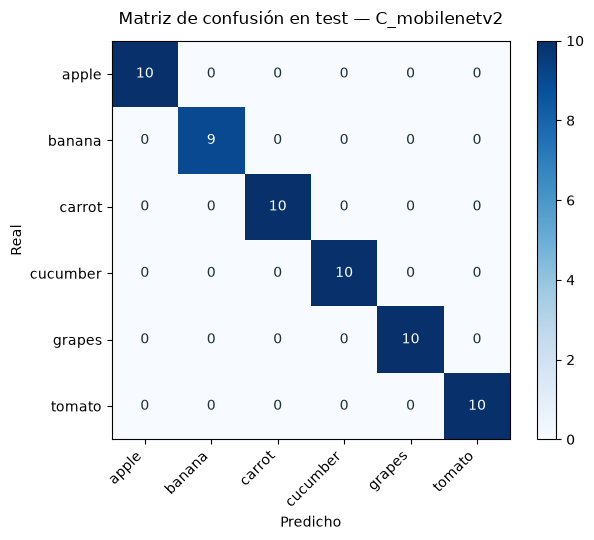

In [12]:
# Matriz de confusion y reporte del mejor modelo, sobre TEST
mejor_modelo = modelos[MEJOR]

flujo_test.reset()
probas = mejor_modelo.predict(flujo_test, verbose=0)
y_pred = probas.argmax(axis=1)
y_real = flujo_test.classes

print(classification_report(y_real, y_pred, target_names=CLASES, digits=3))

mc = confusion_matrix(y_real, y_pred)
fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(mc, cmap="Blues")
ax.set_xticks(range(N_CLASES), CLASES, rotation=45, ha="right")
ax.set_yticks(range(N_CLASES), CLASES)
umbral = mc.max() / 2
for i in range(N_CLASES):
    for j in range(N_CLASES):
        ax.text(j, i, mc[i, j], ha="center", va="center", fontsize=10,
                color="white" if mc[i, j] > umbral else "#20303f")
ax.set_xlabel("Predicho"); ax.set_ylabel("Real")
ax.set_title(f"Matriz de confusión en test — {MEJOR}", fontsize=12, pad=12)
plt.colorbar(im, fraction=0.046)
plt.tight_layout()
plt.savefig(DIR_SALIDAS / "matriz_confusion.png", bbox_inches="tight")
plt.show()

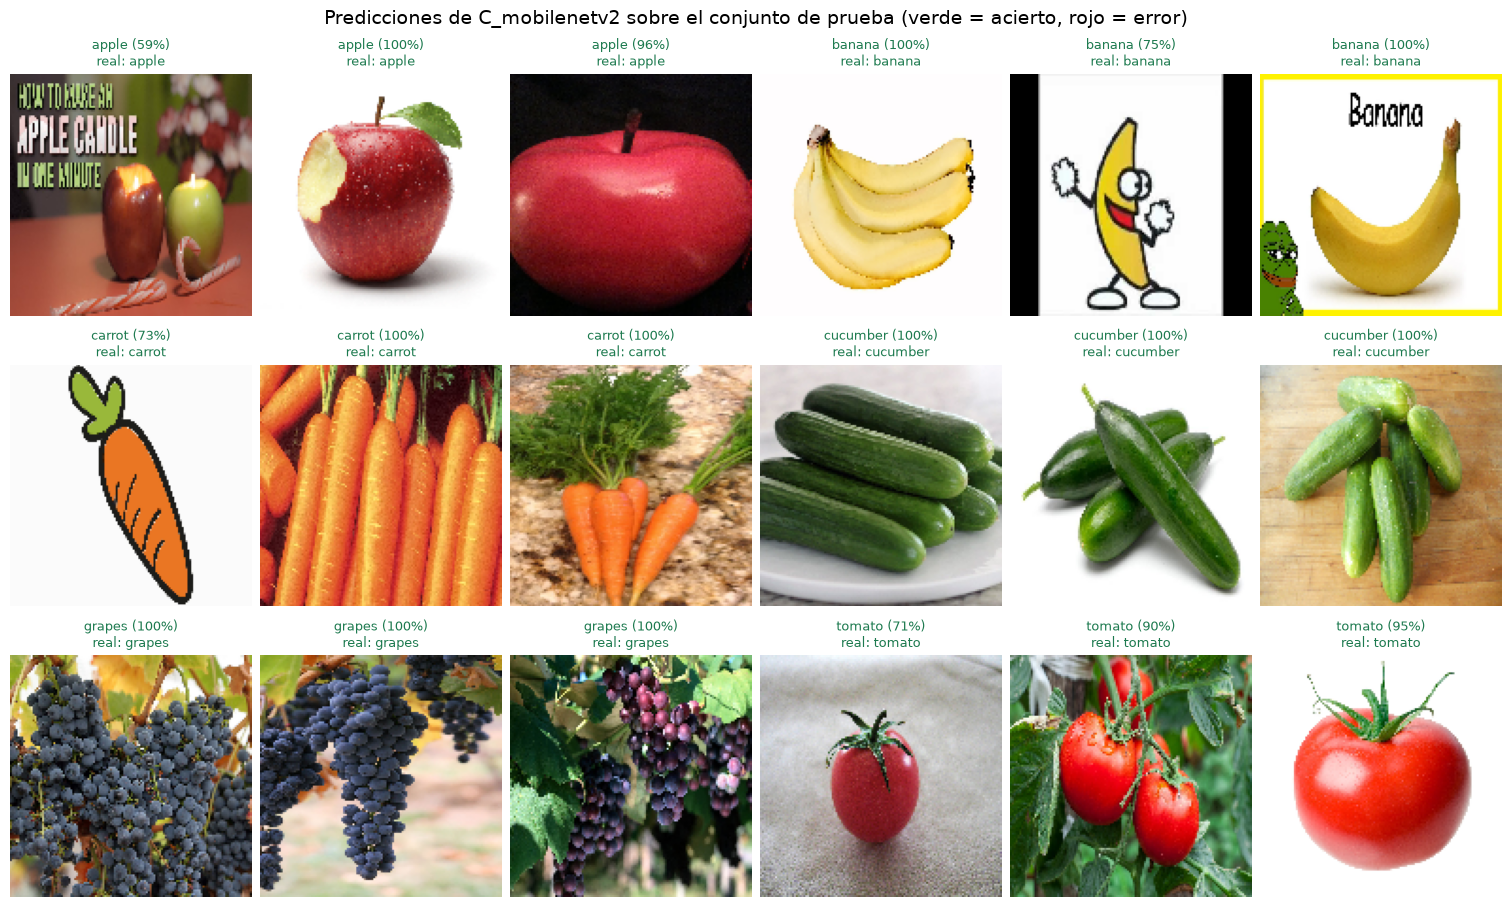

In [13]:
# Predicciones sobre una muestra ESTRATIFICADA del test (3 por clase).
# Nota: flujo_test va sin shuffle, asi que tomar el primer lote daria 32 imagenes
# de la misma clase; se muestrea por clase para ver las seis.
rng = np.random.default_rng(SEMILLA)
indices = np.concatenate([
    rng.choice(np.where(y_real == k)[0],
               size=min(3, (y_real == k).sum()), replace=False)
    for k in range(N_CLASES)
])

# constrained_layout reserva el espacio de los titulos de 2 lineas; con tight_layout
# los rotulos de una fila se encabalgan sobre las imagenes de la fila anterior.
fig, axes = plt.subplots(3, 6, figsize=(15, 9), constrained_layout=True)
for ax in axes.flat:
    ax.axis("off")

for ax, idx in zip(axes.flat, indices):
    ax.imshow(keras.utils.load_img(flujo_test.filepaths[idx], target_size=IMG_SIZE))
    pr = probas[idx]
    ok = pr.argmax() == y_real[idx]
    ax.set_title(f"{CLASES[pr.argmax()]} ({pr.max():.0%})\nreal: {CLASES[y_real[idx]]}",
                 fontsize=9, pad=6, color="#1d7a4f" if ok else "#c9412e")

plt.suptitle(f"Predicciones de {MEJOR} sobre el conjunto de prueba "
             f"(verde = acierto, rojo = error)", fontsize=14)
plt.savefig(DIR_SALIDAS / "predicciones_test.png", bbox_inches="tight")
plt.show()

## 2.6 Respuesta: ¿Por qué la CNN seleccionada funciona mejor que las otras?

### Resultados obtenidos

Evaluación sobre el conjunto de **test** (59 imágenes que ningún modelo vio al entrenar):

| Modelo | Params entrenables | Épocas | Train acc | Val acc | **Test acc** | **Test loss** |
|---|---|---|---|---|---|---|
| **C — MobileNetV2** | **164,742** | 12 | 0.961 | **1.000** | **1.000** | **0.062** |
| B — Profunda + BN | 1,240,550 | 18 | 0.851 | 0.912 | 0.915 | 0.314 |
| A — Baseline | 4,288,454 | 19 | 0.830 | 0.895 | 0.898 | 0.480 |

**La arquitectura C (MobileNetV2 con *transfer learning*) es la que mejor funciona**, y la
razón no es que sea «más grande» —de hecho es la que **menos** parámetros entrena, 26 veces
menos que A— sino **de dónde viene su conocimiento**:

1. **Los filtros ya están aprendidos sobre 1.2 millones de imágenes.** Las primeras capas de
   una CNN aprenden bordes, esquinas, manchas de color y texturas: conocimiento genérico que
   no depende de si la imagen es un gato o una zanahoria. Los modelos A y B tienen que
   aprender eso desde cero con unos pocos miles de fotos; C lo recibe gratis y solo entrena
   la cabeza clasificadora. Con un dataset pequeño, esa diferencia es decisiva.
2. **ImageNet ya contiene frutas y verduras** (`banana`, `orange`, `cucumber`, `zucchini`…),
   así que las representaciones de alto nivel de MobileNetV2 también son relevantes, no solo
   las de bajo nivel.
3. **Menos parámetros entrenables ⇒ menos sobreajuste.** Con la base congelada, C ajusta
   164,742 pesos; el `Flatten` + `Dense(128)` de A genera **4,288,454**, alimentados por solo
   511 imágenes. Esa desproporción es la que A paga en *test loss*: 0.480 contra 0.062 de C,
   casi ocho veces peor pese a que su *accuracy* solo baja 10 puntos.
4. **Converge en muchas menos épocas.** C alcanza el **100 % de validación en la época 4**;
   A necesita 19 épocas para quedarse en 89.5 %. Parte de un punto del espacio de pesos ya
   cercano a una buena solución en lugar de una inicialización aleatoria.

**Por qué B supera a A.** B corrige los dos defectos de A —añade `BatchNormalization`, que
estabiliza el gradiente y permite entrenar más profundo, y sustituye el `Flatten` por
`GlobalAveragePooling`, que elimina la densa masiva—. El resultado es que **con 3.5 veces
menos parámetros entrenables que A obtiene mejor desempeño**. Conviene ser prudente con la
*accuracy*: 0.915 frente a 0.898 es **una sola imagen de diferencia** sobre 59, dentro del
ruido. La señal fiable es el *test loss* (0.314 vs 0.480): B no solo acierta un poco más, sino
que está **mucho menos sobreconfiado** en sus errores. Aun así no alcanza a C, porque sigue
partiendo de pesos aleatorios: su techo lo marca la cantidad de datos, no su diseño.

**Cautela sobre el 100 % de C.** El test tiene 59 imágenes, así que «100 %» significa *no
falló en ninguna de las 59*, no que sea infalible. Con cero errores en 59 ensayos, la regla de
tres sitúa la tasa de error real por debajo de ~5 % con 95 % de confianza. Para afirmar más
haría falta un conjunto de prueba mayor. El par teóricamente más difícil era **apple ↔ tomato**
(ambos esféricos, rojos y brillantes, justo donde el color deja de discriminar); C los separó
sin errores apoyándose en textura y pedúnculo.

**Sobre el *gap* negativo.** Las tres filas muestran `Train acc` **menor** que `Val acc`, que
a primera vista parece imposible. No lo es: las métricas de entrenamiento se calculan sobre
imágenes **aumentadas** (rotadas, oscurecidas, desplazadas) y con `Dropout` activo, mientras
que las de validación usan imágenes limpias y la red completa en modo inferencia. El
entrenamiento resuelve un problema deliberadamente más difícil que la evaluación.

**Sobre la robustez pedida.** La invariancia a tamaño, rotación e iluminación no la da la
arquitectura sino el `ImageDataGenerator`: las tres redes la reciben por igual vía rotación,
zoom, `brightness_range` y `channel_shift`. La arquitectura aporta *capacidad de
representación*; el *augmentation* aporta *invariancia*. Se complementan, no se sustituyen.

**Un detalle revelador de la figura de predicciones.** Las predicciones **menos seguras** son
exactamente las imágenes atípicas del test: una miniatura de vídeo con texto superpuesto
(«APPLE CANDLE», 59 %), un plátano de dibujos animados (75 %) y un pictograma de zanahoria
(73 %) — frente al 96–100 % que obtiene en las fotografías limpias. El modelo **acierta las
tres**, pero su confianza cae justo donde la imagen se aleja de la distribución de
entrenamiento. Es el comportamiento deseable: una red sobreconfiada fuera de su dominio sería
mucho más peligrosa en producción que una que acierta con menos certeza.

---

## Conclusiones del proyecto (cierre de los dos notebooks)

- **Problema 1.** Tres expresiones regulares bastaron para convertir 1.6 M de tweets crudos en
  una respuesta concreta: quiénes son los usuarios más citados y por qué. La clave
  metodológica fue no analizar el tweet completo sino la **ventana de contexto** alrededor de
  la mención, y limpiar el ruido propio de Twitter antes de contar.
- **Problema 2.** Con 511 imágenes de entrenamiento, **la transferencia de conocimiento vence
  al diseño de arquitectura**: MobileNetV2 congelada llega al 100 % en test entrenando 26
  veces menos parámetros que el baseline, que se queda en 89.8 %. Reutilizar filtros
  preentrenados rinde más que añadir capas. El *data augmentation* es lo que da robustez ante
  tamaño, rotación e iluminación, y es independiente de qué red se use.
- **Lección transversal.** En ambos problemas lo decisivo no fue el modelo sino el
  **preprocesamiento**: la ventana de contexto en el Problema 1 y el *augmentation* en el
  Problema 2. Los datos bien preparados pesaron más que la sofisticación del algoritmo.